miaw


In [ ]:
import pandas as pd
import numpy as np

# 1. Memuat dataset dari folder raw
file_path = '../data/raw/cic_ddos_dataset.csv' 
df = pd.read_csv(file_path)

# 2. Membersihkan spasi pada nama kolom 
df.columns = df.columns.str.strip()

# 3. Menampilkan 5 baris pertama data
print("5 Baris Pertama Dataset:")
display(df.head())

# 4. Mengecek total baris dan kolom
print(f"\nTotal Baris: {df.shape[0]}")
print(f"Total Kolom: {df.shape[1]}")

5 Baris Pertama Dataset:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN



Total Baris: 225745
Total Kolom: 79


In [4]:
# Melihat distribusi kelas target (Label)
print("\nDistribusi Label (Normal vs DDoS):")
print(df['Label'].value_counts())

# Melihat persentasenya
print("\nPersentase Label:")
print(df['Label'].value_counts(normalize=True) * 100)


Distribusi Label (Normal vs DDoS):
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

Persentase Label:
Label
DDoS      56.713105
BENIGN    43.286895
Name: proportion, dtype: float64


In [ ]:
import numpy as np

# 1. Mengubah nilai Infinite (tak terhingga) menjadi NaN (kosong)
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. Mengecek berapa banyak baris data yang kotor (mengandung NaN)
kotor_awal = df.isna().sum().sum()
print(f"Jumlah nilai kotor (NaN/Inf) sebelum dibersihkan: {kotor_awal}")

# 3. Menghapus seluruh baris yang mengandung nilai kosong tersebut
df.dropna(inplace=True)

# 4. Memastikan data sudah benar-benar bersih
kotor_akhir = df.isna().sum().sum()
print(f"Jumlah nilai kotor setelah dibersihkan: {kotor_akhir}")
print(f"Total baris data yang siap digunakan sekarang: {df.shape[0]}")

Jumlah nilai kotor (NaN/Inf) sebelum dibersihkan: 68
Jumlah nilai kotor setelah dibersihkan: 0
Total baris data yang siap digunakan sekarang: 225711


In [ ]:
# SOAL 2

C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_13240\2451677203.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Label', palette='viridis')


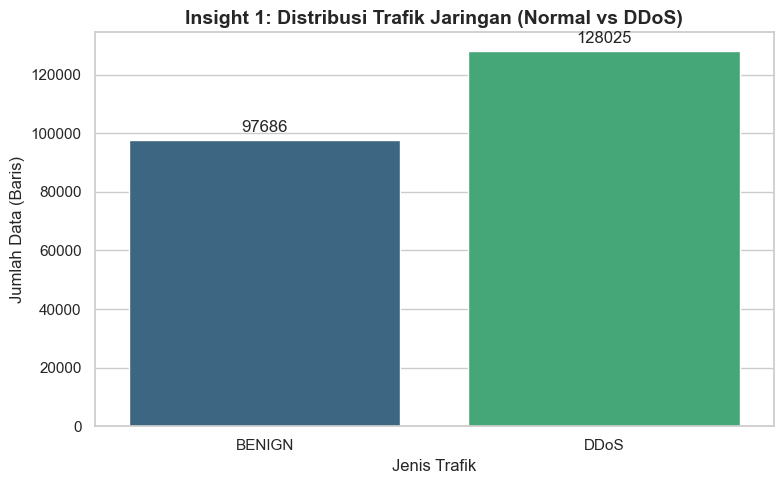

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur gaya grafik 
sns.set_theme(style="whitegrid")

# Membuat kanvas grafik
plt.figure(figsize=(8, 5))

# Membuat Bar Chart distribusi label
ax = sns.countplot(data=df, x='Label', palette='viridis')

# Menambahkan judul dan label sumbu
plt.title('Insight 1: Distribusi Trafik Jaringan (Normal vs DDoS)', fontsize=14, fontweight='bold')
plt.xlabel('Jenis Trafik', fontsize=12)
plt.ylabel('Jumlah Data (Baris)', fontsize=12)

# Menambahkan angka di atas batang grafik 
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

In [ ]:
# 1. Encoding Kolom Target
df['Label'] = df['Label'].apply(lambda x: 0 if 'BENIGN' in str(x).upper() else 1)

# 2. Menghapus kolom yang tidak memiliki variansi (nilainya sama semua di setiap baris)
df_cleaned = df.loc[:, df.nunique() > 1].copy()

print(f"Jumlah kolom sebelum seleksi: {df.shape[1]}")
print(f"Jumlah kolom setelah membuang kolom statis: {df_cleaned.shape[1]}")

Jumlah kolom sebelum seleksi: 79
Jumlah kolom setelah membuang kolom statis: 68



--- 10 FITUR PALING BERPENGARUH ---
Bwd Packet Length Mean    0.603258
Avg Bwd Segment Size      0.603258
Bwd Packet Length Max     0.577287
Bwd Packet Length Std     0.576122
Destination Port          0.509768
URG Flag Count            0.463294
Packet Length Mean        0.454211
Average Packet Size       0.453399
Packet Length Std         0.443681
Min Packet Length         0.427484
Name: Label, dtype: float64


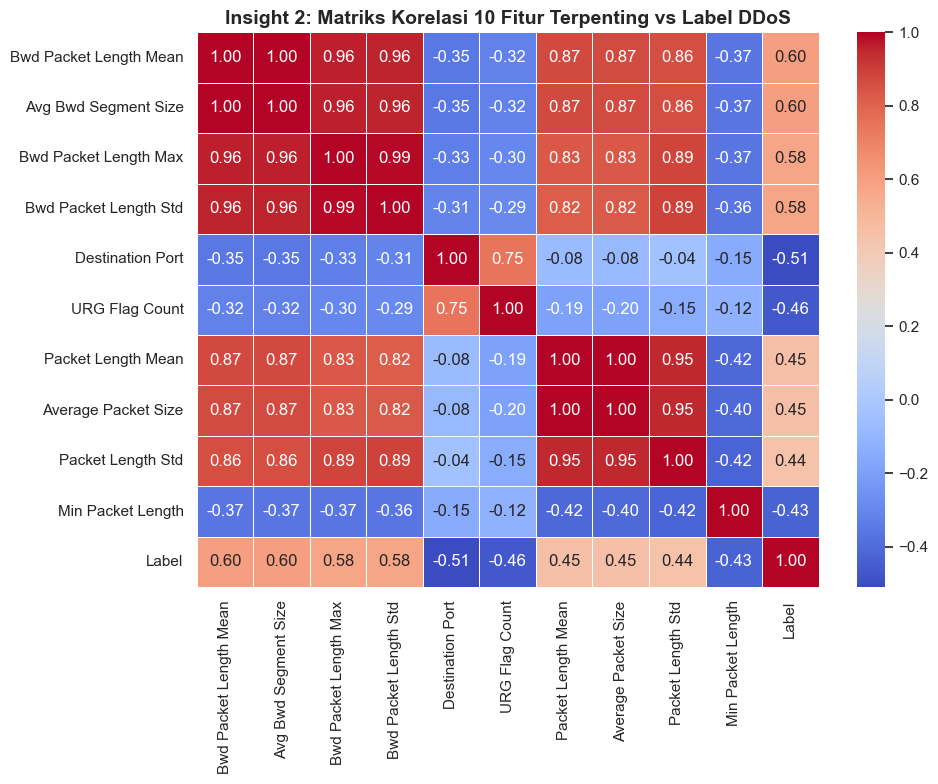


[SUKSES] Dataset siap untuk dilatih dengan LightGBM!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD ULANG DATA (Agar bersih dari eksekusi cell sebelumnya)
file_path = '../data/raw/cic_ddos_dataset.csv' 
df = pd.read_csv(file_path)

# 2. UBAH NAMA KOLOM TERAKHIR MENJADI 'Label'
target_col = df.columns[-1] 
df.rename(columns={target_col: 'Label'}, inplace=True)

# 3. Bersihkan spasi di nama-nama kolom lainnya
df.columns = df.columns.str.strip()

# 4. Bersihkan data kotor (Infinite dan Missing Values)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# 5. Lakukan Label Encoding (Benign = 0, DDoS = 1)
df['Label'] = df['Label'].apply(lambda x: 0 if 'BENIGN' in str(x).upper() else 1)
df['Label'] = pd.to_numeric(df['Label'])

# 6. Hapus kolom statis (KECUALI kolom 'Label' agar aman)
cols_to_keep = [c for c in df.columns if df[c].nunique() > 1 or c == 'Label']
df_cleaned = df[cols_to_keep].copy()

# 7. Ambil hanya kolom numerik dan hitung korelasi
numeric_df = df_cleaned.select_dtypes(include=[np.number])

# --- Proses Visualisasi Heatmap ---
# Hitung korelasi
correlations = numeric_df.corr()['Label'].abs().sort_values(ascending=False)

# Ambil 10 fitur terbaik
top_10_features = correlations.index[1:11]
print("\n--- 10 FITUR PALING BERPENGARUH ---")
print(correlations[1:11])

# Gambar Heatmap Matriks Korelasi
plt.figure(figsize=(10, 8))
top_features_data = numeric_df[top_10_features.tolist() + ['Label']]
correlation_matrix_top = top_features_data.corr()

sns.heatmap(correlation_matrix_top, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Insight 2: Matriks Korelasi 10 Fitur Terpenting vs Label DDoS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Simpan variabel X (Fitur) dan y (Target)
X = df_cleaned[top_10_features]
y = df_cleaned['Label']

In [ ]:
# SOAL 3

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import lightgbm as lgb
import xgboost as xgb
import time

# 1. Pembagian Data (Train-Test Split)
# Membagi data menjadi 80% untuk pelatihan (training) dan 20% untuk pengujian (testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Jumlah data training: {X_train.shape[0]} baris")
print(f"Jumlah data testing: {X_test.shape[0]} baris\n")

# ==========================================
# 2. PELATIHAN MODEL 1: LightGBM (Model Utama)
# ==========================================
print("Melatih model LightGBM...")
lgb_model = lgb.LGBMClassifier(random_state=42)

# Mengukur waktu training LightGBM
start_train_lgb = time.time()
lgb_model.fit(X_train, y_train)
end_train_lgb = time.time()

# Mengukur waktu inferensi (deteksi) LightGBM
start_infer_lgb = time.time()
y_pred_lgb = lgb_model.predict(X_test)
end_infer_lgb = time.time()

lgb_train_time = end_train_lgb - start_train_lgb
lgb_infer_time = (end_infer_lgb - start_infer_lgb) * 1000 # Konversi ke milidetik

# ==========================================
# 3. PELATIHAN MODEL 2: XGBoost (Model Pembanding)
# ==========================================
print("Melatih model XGBoost...")
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Mengukur waktu training XGBoost
start_train_xgb = time.time()
xgb_model.fit(X_train, y_train)
end_train_xgb = time.time()

# Mengukur waktu inferensi (deteksi) XGBoost
start_infer_xgb = time.time()
y_pred_xgb = xgb_model.predict(X_test)
end_infer_xgb = time.time()

xgb_train_time = end_train_xgb - start_train_xgb
xgb_infer_time = (end_infer_xgb - start_infer_xgb) * 1000 # Konversi ke milidetik

# ==========================================
# 4. EVALUASI DAN PERBANDINGAN PERFORMA
# ==========================================
print("\n" + "="*50)
print("HASIL EVALUASI MODEL")
print("="*50)

def evaluate_model(y_true, y_pred, model_name, train_time, infer_time):
    print(f"\n--- {model_name} ---")
    print(f"Accuracy  : {accuracy_score(y_true, y_pred) * 100:.2f}%")
    print(f"Precision : {precision_score(y_true, y_pred) * 100:.2f}%")
    print(f"Recall    : {recall_score(y_true, y_pred) * 100:.2f}%")
    print(f"F1-Score  : {f1_score(y_true, y_pred) * 100:.2f}%")
    print(f"Waktu Training  : {train_time:.4f} detik")
    print(f"Waktu Inferensi : {infer_time:.4f} milidetik")

evaluate_model(y_test, y_pred_lgb, "LightGBM", lgb_train_time, lgb_infer_time)
evaluate_model(y_test, y_pred_xgb, "XGBoost", xgb_train_time, xgb_infer_time)

Jumlah data training: 180568 baris
Jumlah data testing: 45143 baris

Melatih model LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 102420, number of negative: 78148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000850 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2076
[LightGBM] [Info] Number of data points in the train set: 180568, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567210 -> initscore=0.270478
[LightGBM] [Info] Start training from score 0.270478
Melatih model XGBoost...


C:\Users\HP VICTUS\AppData\Roaming\Python\Python314\site-packages\xgboost\training.py:200: UserWarning: [11:57:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



HASIL EVALUASI MODEL

--- LightGBM ---
Accuracy  : 99.93%
Precision : 99.93%
Recall    : 99.95%
F1-Score  : 99.94%
Waktu Training  : 0.2385 detik
Waktu Inferensi : 23.3772 milidetik

--- XGBoost ---
Accuracy  : 99.95%
Precision : 99.98%
Recall    : 99.93%
F1-Score  : 99.96%
Waktu Training  : 0.2125 detik
Waktu Inferensi : 12.2499 milidetik


C:\Users\HP VICTUS\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-07-17 12:04:22,170] A new study created in memory with name: no-name-5d003386-c096-4ec1-8887-567ef9274bf6


Memulai pencarian hyperparameter terbaik dengan Optuna...


[I 2026-07-17 12:04:22,476] Trial 0 finished with value: 0.9993575969696299 and parameters: {'learning_rate': 0.11053675265323411, 'num_leaves': 55, 'max_depth': 9}. Best is trial 0 with value: 0.9993575969696299.
[I 2026-07-17 12:04:22,748] Trial 1 finished with value: 0.9993797487982633 and parameters: {'learning_rate': 0.0711843966080125, 'num_leaves': 34, 'max_depth': 5}. Best is trial 1 with value: 0.9993797487982633.
[I 2026-07-17 12:04:23,002] Trial 2 finished with value: 0.9993797487982633 and parameters: {'learning_rate': 0.16839459751237804, 'num_leaves': 59, 'max_depth': 5}. Best is trial 1 with value: 0.9993797487982633.
[I 2026-07-17 12:04:23,339] Trial 3 finished with value: 0.9993354451409964 and parameters: {'learning_rate': 0.11039414910644864, 'num_leaves': 84, 'max_depth': 9}. Best is trial 1 with value: 0.9993797487982633.
[I 2026-07-17 12:04:23,692] Trial 4 finished with value: 0.9993354451409964 and parameters: {'learning_rate': 0.11254750512596587, 'num_leaves': 


[SELESAI] Parameter Terbaik Ditemukan:
{'learning_rate': 0.0711843966080125, 'num_leaves': 34, 'max_depth': 5}

Model final telah dilatih dengan parameter terbaik.

Memproses visualisasi SHAP...


C:\Users\HP VICTUS\AppData\Roaming\Python\Python314\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


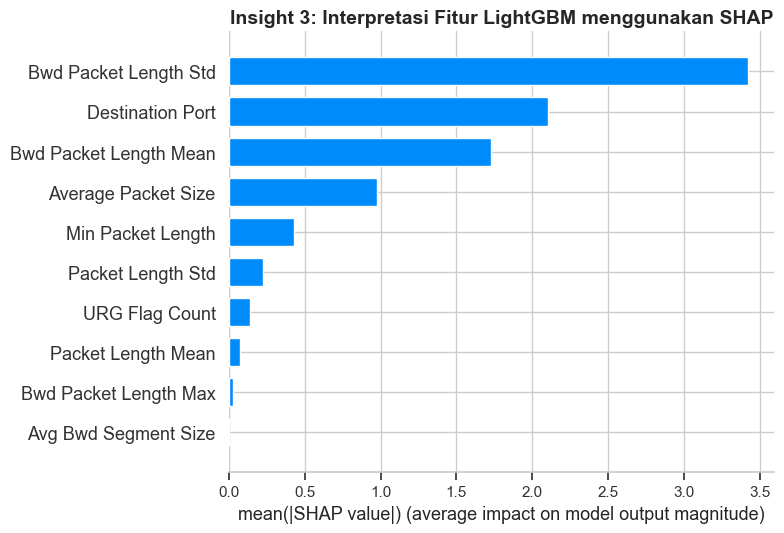


[SUKSES] Model terbaik telah diekstrak dan disimpan di: ../models/best_lgb_model.pkl
Tahap SOAL 3 resmi selesai! Bersiap untuk pembuatan aplikasi Streamlit.


In [ ]:
import optuna
import shap
import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import os

# ==========================================
# 1. HYPERPARAMETER TUNING DENGAN OPTUNA
# ==========================================
print("Memulai pencarian hyperparameter terbaik dengan Optuna...")

def objective(trial):
    param = {
        'random_state': 42,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
    }
    
    # Melatih model dengan parameter uji coba
    model = lgb.LGBMClassifier(**param, verbose=-1)
    model.fit(X_train, y_train)
    
    # Menguji model
    preds = model.predict(X_test)
    accuracy = accuracy_score(y_test, preds)
    return accuracy

# Membuat "study" Optuna untuk mencari akurasi tertinggi (maximize)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print("\n[SELESAI] Parameter Terbaik Ditemukan:")
print(study.best_params)

# ==========================================
# 2. MELATIH MODEL FINAL
# ==========================================
# Melatih ulang LightGBM menggunakan parameter paling optimal dari Optuna
best_lgb_model = lgb.LGBMClassifier(**study.best_params, random_state=42, verbose=-1)
best_lgb_model.fit(X_train, y_train)
print("\nModel final telah dilatih")

# ==========================================
# 3. INTERPRETASI MODEL (SHAP) - Insight ke-3
# ==========================================
# Syarat UAS: Menampilkan feature importance menggunakan SHAP
print("\nMemproses visualisasi SHAP...")
explainer = shap.TreeExplainer(best_lgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
# Membuat plot bar SHAP
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Insight 3: Interpretasi Fitur LightGBM menggunakan SHAP", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 4. MENYIMPAN MODEL (DEPLOYMENT PREPARATION)
# ==========================================
# Membuat folder 'models' jika belum ada di dalam workspace
os.makedirs('../models', exist_ok=True)

model_path = '../models/best_lgb_model.pkl'
joblib.dump(best_lgb_model, model_path)

print(f"\n[SUKSES] Model terbaik telah diekstrak dan disimpan di: {model_path}")